In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# 1. Load Data
df = pd.read_csv('leakage_data_export.csv')
df['leakage_date'] = pd.to_datetime(df['leakage_date'], dayfirst=True)

In [21]:
# 2. High-Level Check
print(f"Rows Loaded: {len(df)}")
print(f"Total Revenue Lost: ${df['leakage_amount'].sum():,.2f}")
display(df.head())

Rows Loaded: 549
Total Revenue Lost: $18,348.15


,leakage_date,leakage_category,leakage_amount,plan_name,region
0,2024-01-01,Partial Payment,0.96,Basic,East
1,2024-01-01,Unpaid Invoice,50.00,Pro,North
2,2024-01-01,Unpaid Invoice,10.00,Basic,East
3,2024-01-01,Partial Payment,6.91,Enterprise,West
4,2024-01-01,Partial Payment,14.73,Enterprise,South


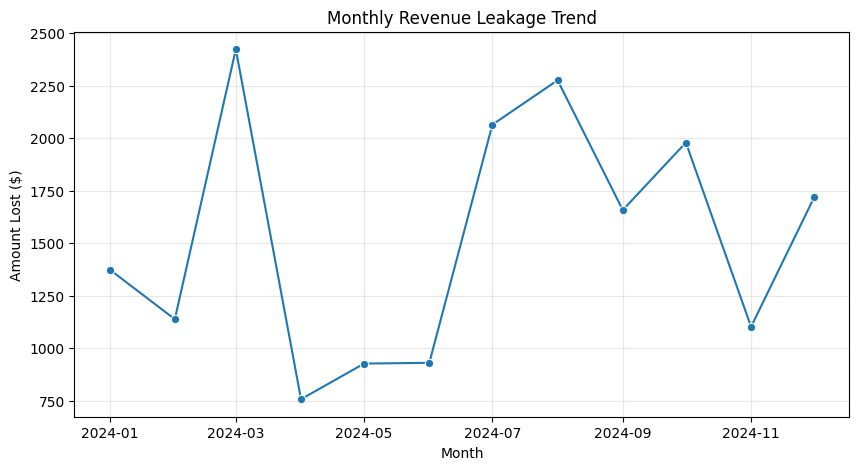

In [22]:
# 3. Monthly Leakage Trend
monthly = (
    df.groupby(df['leakage_date'].dt.to_period('M'))['leakage_amount']
      .sum()
      .reset_index()
)
monthly['leakage_date'] = monthly['leakage_date'].dt.to_timestamp()

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly, x='leakage_date', y='leakage_amount', marker='o')
plt.title('Monthly Revenue Leakage Trend')
plt.ylabel('Amount Lost ($)')
plt.xlabel('Month')
plt.grid(alpha=0.3)
plt.show()

C:\Users\Dhank\AppData\Local\Temp\ipykernel_2312\2490621481.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


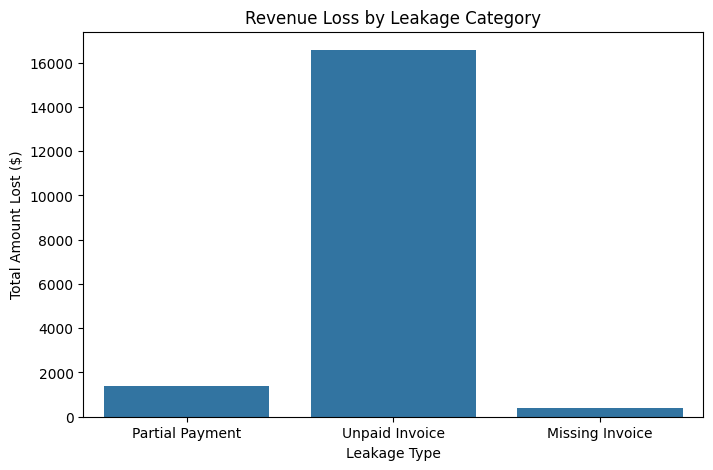

In [23]:
# 4. Leakage by Category
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x='leakage_category',
    y='leakage_amount',
    estimator=sum,
    ci=None
)
plt.title('Revenue Loss by Leakage Category')
plt.ylabel('Total Amount Lost ($)')
plt.xlabel('Leakage Type')
plt.show()

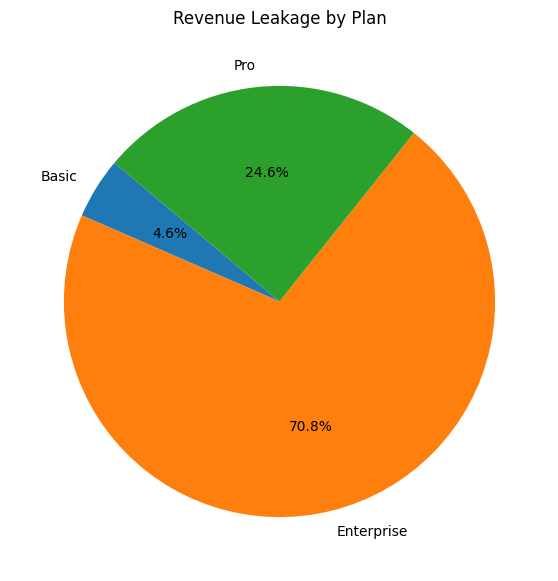

In [24]:
# 5. Leakage by Plan
plan_loss = df.groupby('plan_name')['leakage_amount'].sum()

plt.figure(figsize=(7, 7))
plt.pie(
    plan_loss,
    labels=plan_loss.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Revenue Leakage by Plan')
plt.show()

In [25]:
# 6. Statistical Summary
print("\nDescriptive Statistics by Category:")
display(df.groupby('leakage_category')['leakage_amount'].describe())


Descriptive Statistics by Category:


,count,mean,std,min,25%,50%,75%,max
leakage_category,,,,,,,,
Missing Invoice,13.0,31.538462,20.754981,10.00,10.000,50.00,50.00,50.00
Partial Payment,327.0,4.183945,4.993946,0.11,0.705,2.28,4.81,19.93
Unpaid Invoice,209.0,79.282297,78.629864,10.00,10.000,50.00,200.00,200.00
